## Python

### Tuning algorithms in Python

running simulation: 100%|██████████| 200/200 [00:03<00:00, 60.06it/s]


# Question 1: Acceptance Rate vs. L (at constant width)

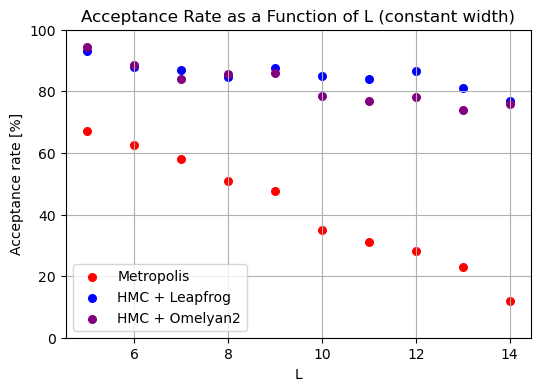

# Question 2: Constant acceptance rate via adapted width

Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


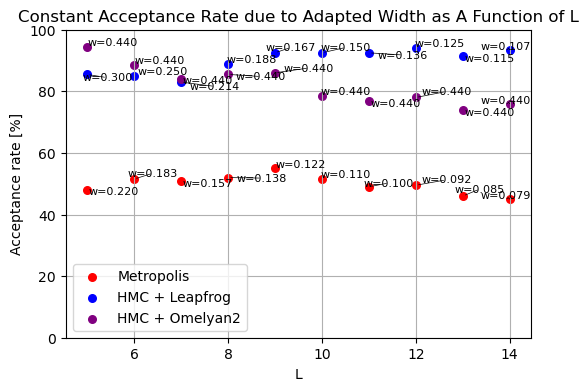

In [1]:
from IPython.display import display, Markdown
import numpy as np
import matplotlib.pyplot as plt
from adjustText import adjust_text


from algorithms.metropolis import run_metropolis
from algorithms.hmc import run_hmc
import algorithms.integrators as integrators

#initialize parameters 
L_vals = list(range(5, 15))
m2 = -0.5
lam = 5.0
rng = np.random.default_rng(seed=42)

#storage of the results
results = {
    "Metropolis": {"const": [], "adapt": [], "widths": []},
    "HMC + Leapfrog": {"const": [], "adapt": [], "widths": []},
    "HMC + Omelyan2": {"const": [], "adapt": [], "widths": []},
}

for L in L_vals:
    phi_field = rng.random(size=(L, L))

    #metropolis
    w = 0.14
    w_adapt = 1.1 / L
    results["Metropolis"]["widths"].append(w_adapt)
    results["Metropolis"]["const"].append(
        np.mean(run_metropolis(phi_field, m2, lam, w, 200, rng)) * 100 # in percent 
    )
    results["Metropolis"]["adapt"].append(
        np.mean(run_metropolis(phi_field, m2, lam, w_adapt, 200, rng)) * 100
    )

    #HMC + Leapfrog 
    w = 0.2
    w_adapt = 1.5 / L
    results["HMC + Leapfrog"]["widths"].append(w_adapt)
    results["HMC + Leapfrog"]["const"].append(
        np.mean(run_hmc(phi_field, m2, lam, w, 200, rng)) * 100
    )
    results["HMC + Leapfrog"]["adapt"].append(
        np.mean(run_hmc(phi_field, m2, lam, w_adapt, 200, rng)) * 100
    )

    #HMC + Omelyan
    w = 0.44
    w_adapt = 0.44
    results["HMC + Omelyan2"]["widths"].append(w_adapt)
    results["HMC + Omelyan2"]["const"].append(
        np.mean(run_hmc(phi_field, m2, lam, w, 200, rng,
                         integrator=integrators.omelyan2)) * 100
    )
    results["HMC + Omelyan2"]["adapt"].append(
        np.mean(run_hmc(phi_field, m2, lam, w_adapt, 200, rng,
                         integrator=integrators.omelyan2)) * 100
    )

# Plot 1: Constant width plot
display(Markdown("# Question 1: Acceptance Rate vs. L (at constant width)"))

colors = ["red", "blue", "purple"]

plt.figure(figsize=(6, 4))
for (name, data), color, in zip(results.items(), colors):
    plt.scatter(L_vals, data["const"], s=30, label=name, color = color)

plt.xlabel("L")
plt.ylabel("Acceptance rate [%]")
plt.title("Acceptance Rate as a Function of L (constant width)")
plt.ylim(0, 100)
plt.grid(True)
plt.legend()
plt.show()

# Plot 2: Adapted width plot
display(Markdown("# Question 2: Constant acceptance rate via adapted width"))

plt.figure(figsize=(6, 4))
texts = []

for (name, data), color in zip(results.items(), colors):
    plt.scatter(L_vals, data["adapt"], s=30, label=name, color = color)

    for L, acc, w in zip(L_vals, data["adapt"], data["widths"]):
        texts.append(
            plt.text(L, acc, f"w={w:.3f}", fontsize=8)
        )

# Automatically move labels to avoid overlaps, works a bit
adjust_text(
    texts,
    arrowprops=dict(arrowstyle="-", lw=0.5),
    expand_points=(1.2, 1.2),
    expand_text=(1.2, 1.2),
)

plt.xlabel("L")
plt.ylabel("Acceptance rate [%]")
plt.title("Constant Acceptance Rate due to Adapted Width as A Function of L")
plt.ylim(0, 100)
plt.grid(True)
plt.legend()
plt.show()


### Generating data with Python, this takes around 1670 mins

In [2]:
import numpy as np
import time
from tqdm import tqdm
from physics.observables import sample_observable
from algorithms import integrators

L_vals = list(range(4, 12))  

num_samples = 45_360 #166320  # highly composite number https://en.wikipedia.org/wiki/Highly_composite_number
rng = np.random.default_rng(seed=42)

algorithms = {
    "Metropolis": {
        "algorithm": "Metropolis",
        "width_factor": lambda L: 1.1 / L,        
    },
    "HMC_leapfrog": {
        "algorithm": "HMC",
        "integrator": integrators.leapfrog,
        "width_factor": lambda L: 1.5 / L,     
    },
    "HMC_omelyan2": {
        "algorithm": "HMC",
        "integrator": integrators.omelyan2,
        "width_factor": lambda L: 0.44,    
    },
}

# Define two  phases
phases = {
    "broken": {"m2": -0.5, "lam": 5.0},
    "symmetric": {"m2": +0.5, "lam": 5.0}
}

for phase_name, params in phases.items():
    m2 = params["m2"]
    lam = params["lam"]

    print(f"\nRunning {phase_name} phase (m2={m2}, lambda={lam})")

    for L in tqdm(L_vals, desc=f"{phase_name} phase: lattice sizes"):
        initial_phi = rng.random(size=(L, L))
        width_normal = 1 / L

        data_dict = {}
        runtimes = {}
        acceptance_rates = {}

        for alg_name, alg_opts in algorithms.items():
            kwargs = alg_opts.copy()
            width_factor = kwargs.pop("width_factor", 1.0)
            
            if callable(width_factor):
                width = width_factor(L)
            else:
                width = width_normal * width_factor

            t0 = time.perf_counter()
            measurements, accepted = sample_observable(
                initial_phi=initial_phi,
                num_samples=num_samples,
                mass2=m2,
                lamb=lam,
                width=width,
                rng=rng,
                observable=None,
                **kwargs
            )
            t1 = time.perf_counter()

            acceptance_rate = np.mean(accepted)

            print(
                f"{alg_name:15s} | L = {L:2d} | "
                f"width = {width:.4f} | "
                f"acceptance = {acceptance_rate:.3f}"
            )

            data_dict[f"{alg_name}_L{L}"] = measurements.astype(np.float32)
            runtimes[f"{alg_name}_L{L}"] = t1 - t0
            acceptance_rates[f"{alg_name}_L{L}"] = acceptance_rate


        meas_filename = (
            f"observable_measurements_{phase_name}_"
            f"m2{m2}_lam{lam}_L{L}_all_algs.npz"
        )
        time_filename = (
            f"observable_runtimes_{phase_name}_"
            f"m2{m2}_lam{lam}_L{L}_all_algs.npz"
        )

        np.savez(meas_filename, **data_dict)
        np.savez(time_filename, **runtimes)


Running broken phase (m2=-0.5, lambda=5.0)


broken phase: lattice sizes:   0%|          | 0/8 [00:00<?, ?it/s]

Sampling (Metropolis):   0%|          | 0/45360 [00:00<?, ?it/s]

Metropolis      | L =  4 | width = 0.2750 | acceptance = 0.506


Sampling (HMC):   0%|          | 0/45360 [00:00<?, ?it/s]

...

Sampling (HMC):   0%|          | 0/45360 [00:00<?, ?it/s]

HMC_leapfrog    | L = 11 | width = 0.1364 | acceptance = 0.920


Sampling (HMC):   0%|          | 0/45360 [00:00<?, ?it/s]

symmetric phase: lattice sizes: 100%|██████████| 8/8 [3:20:44<00:00, 1505.58s/it]

HMC_omelyan2    | L = 11 | width = 0.4400 | acceptance = 0.846


### Thermalization plots

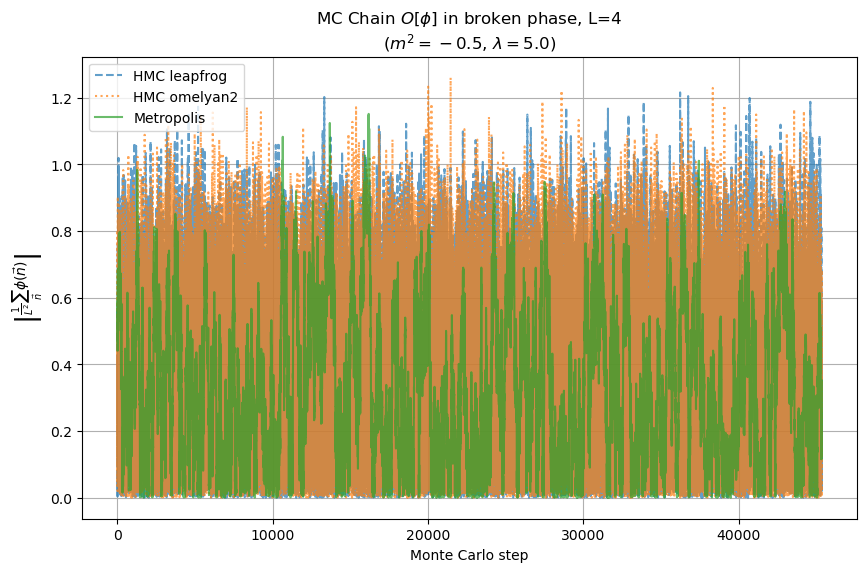

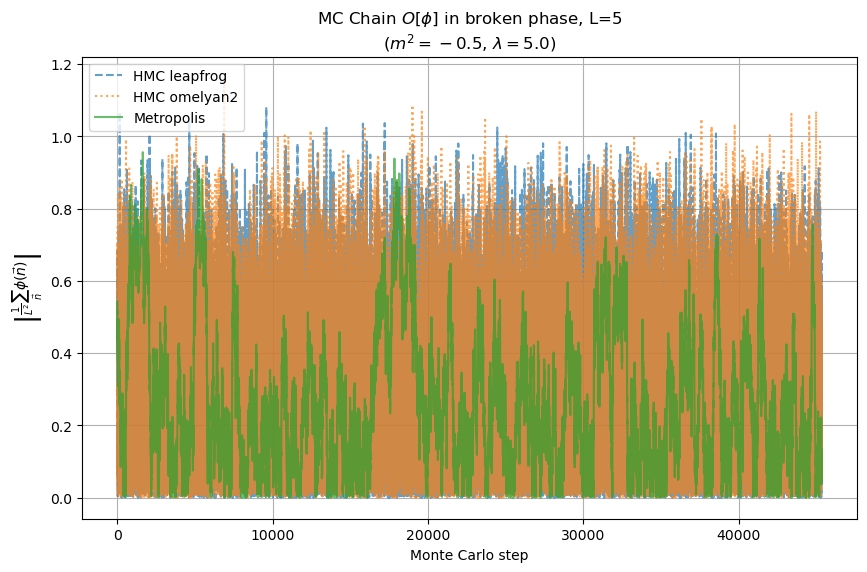

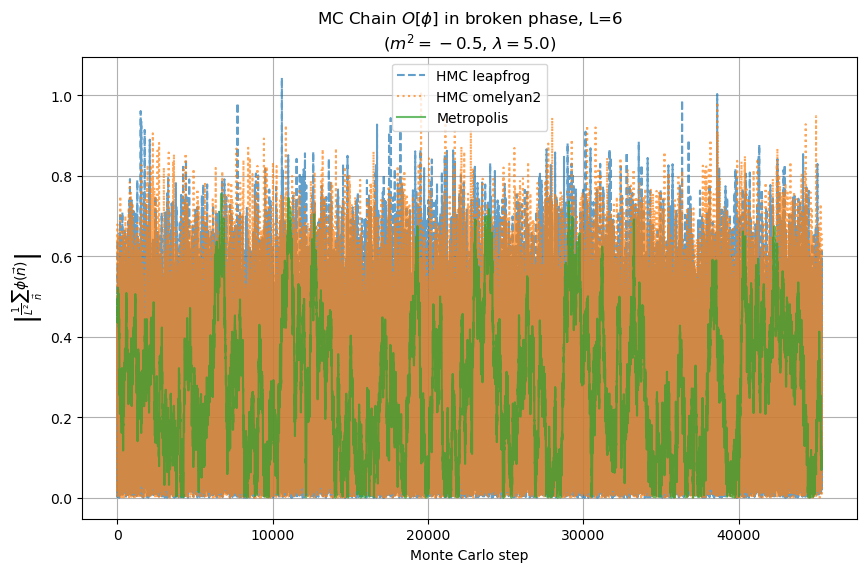

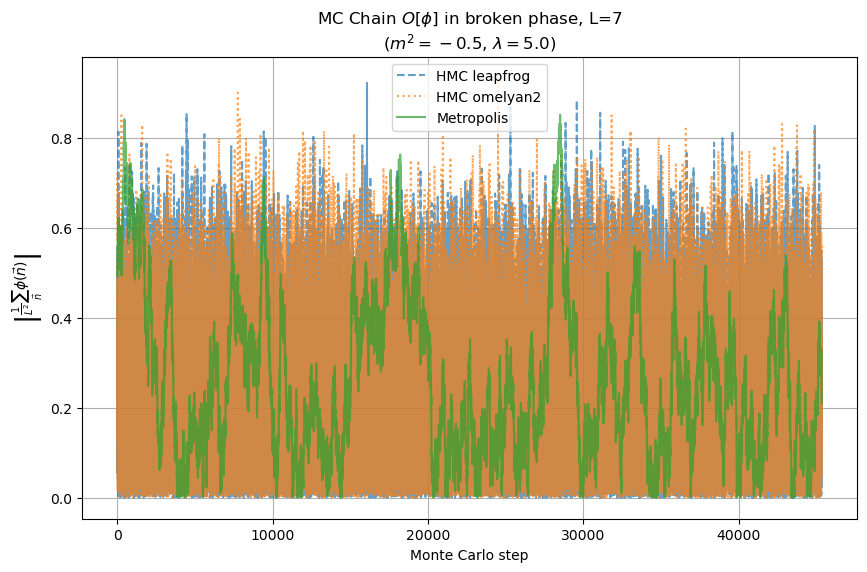

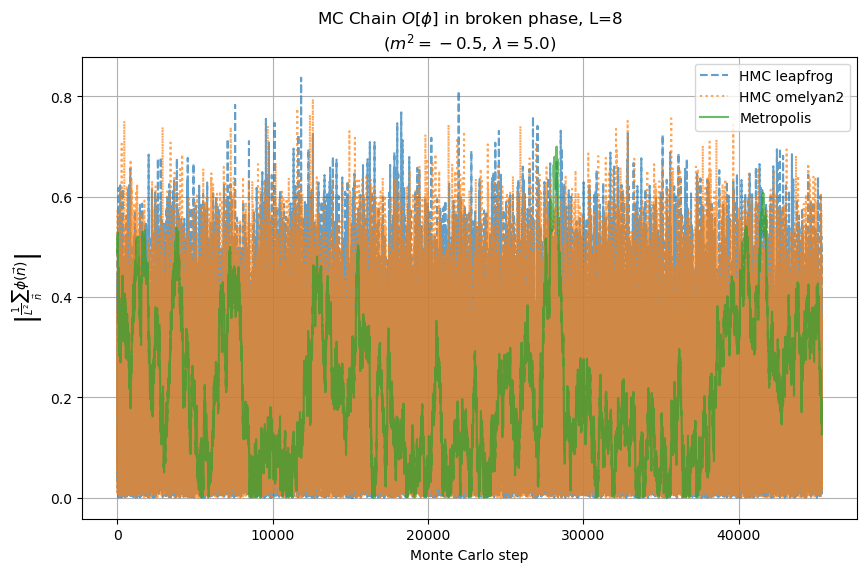

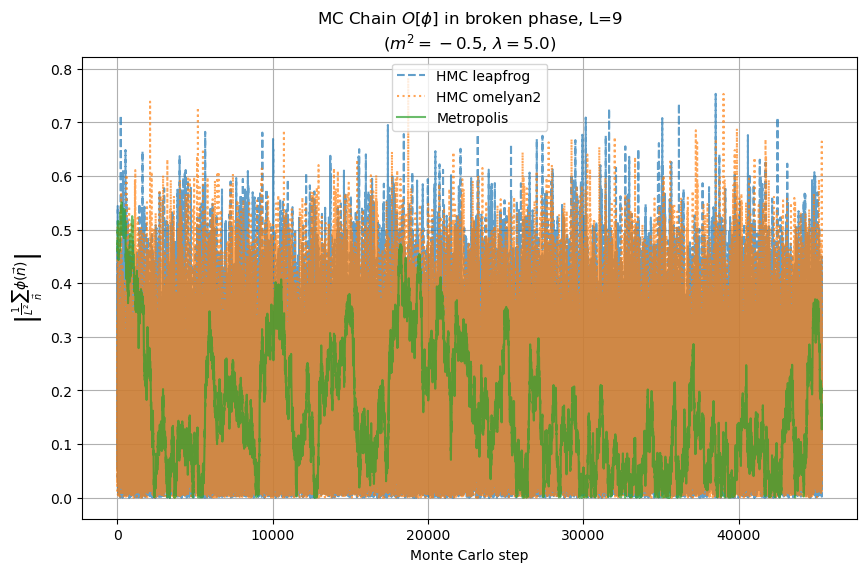

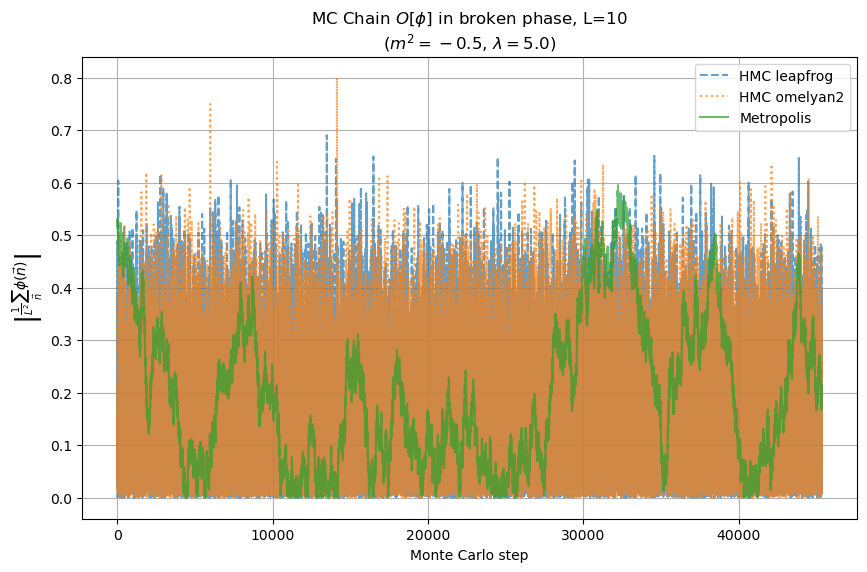

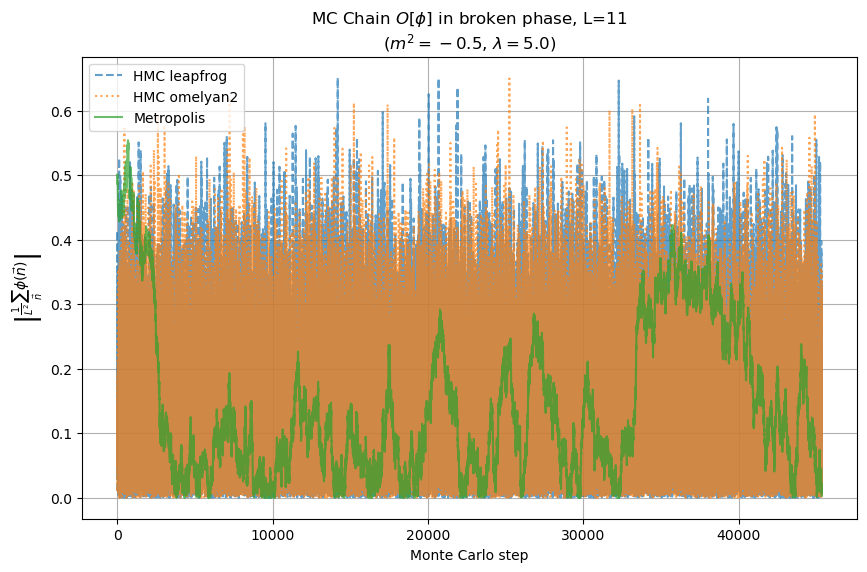

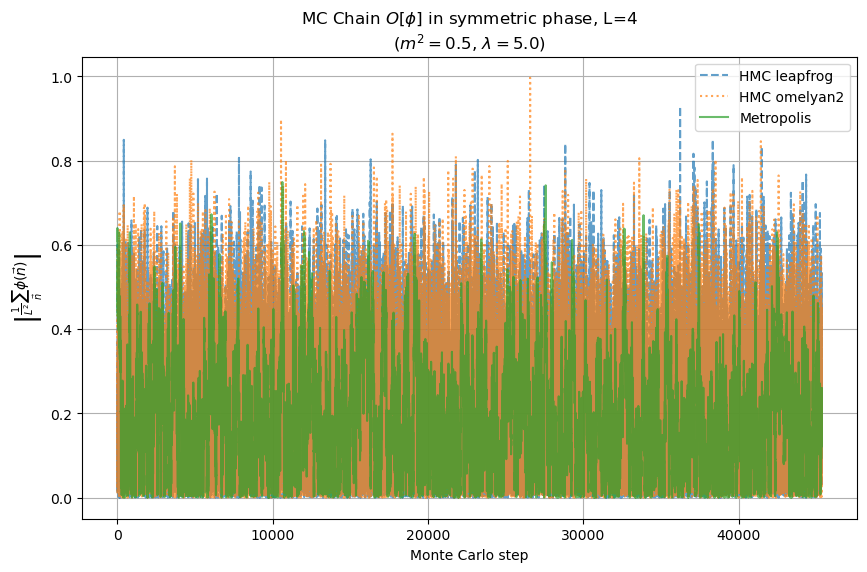

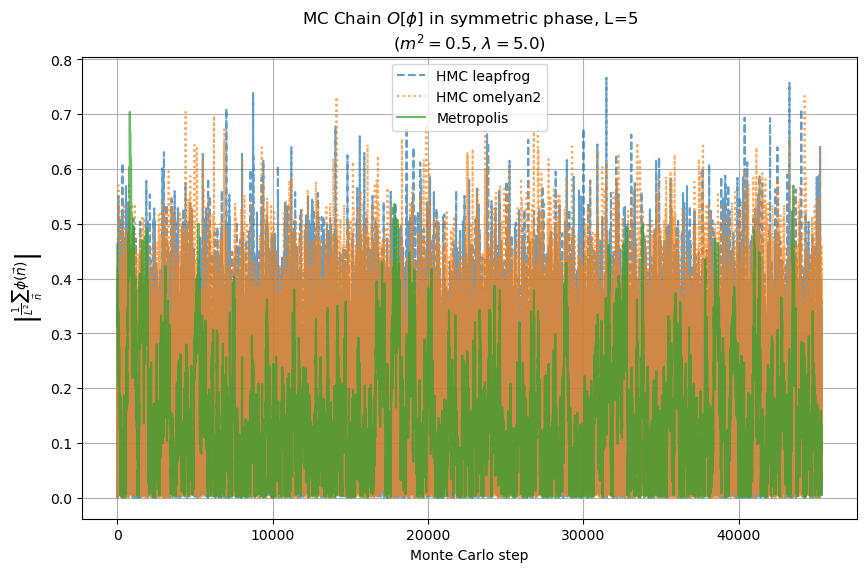

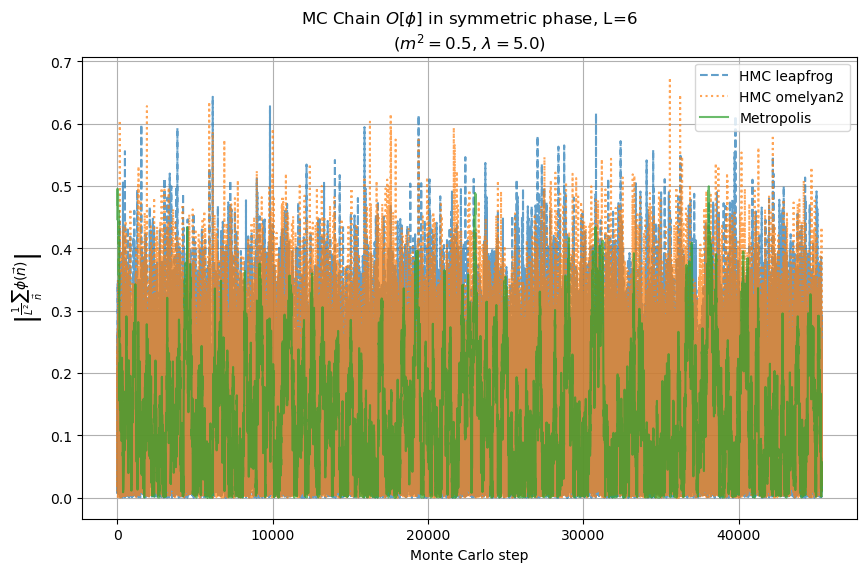

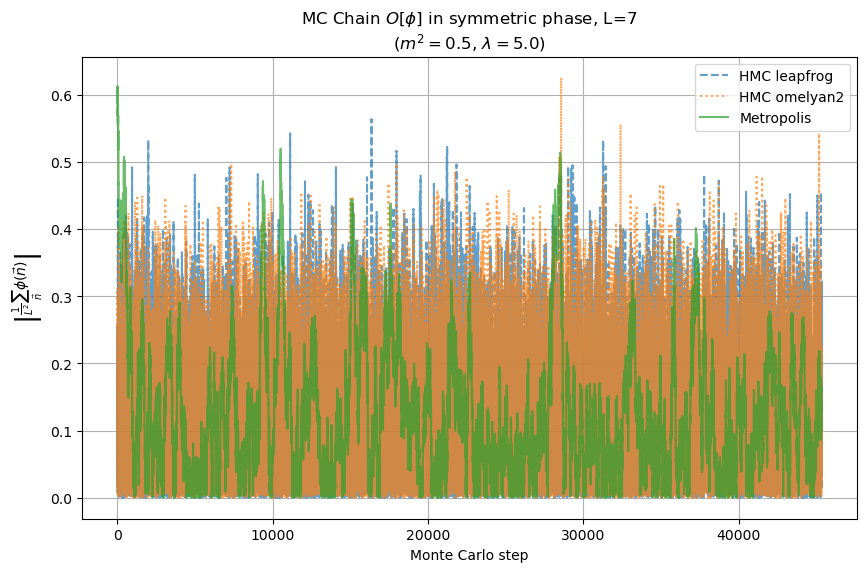

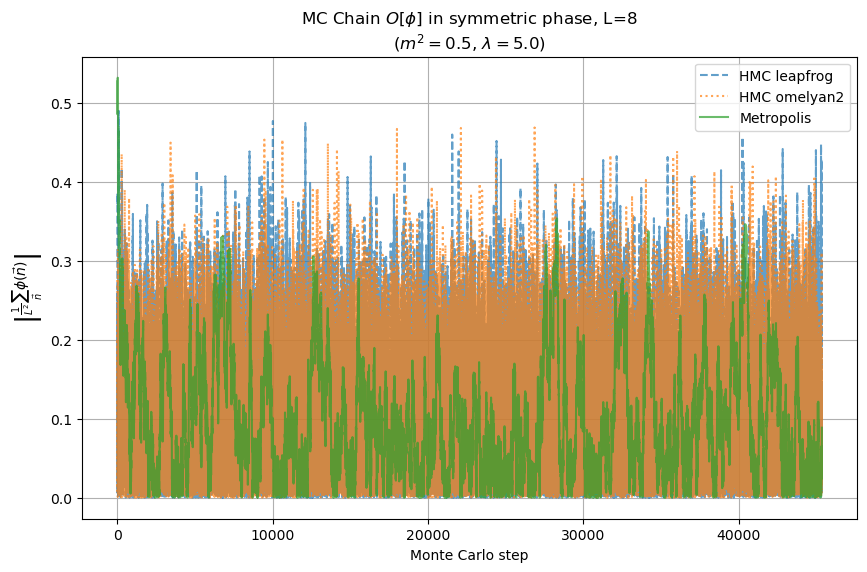

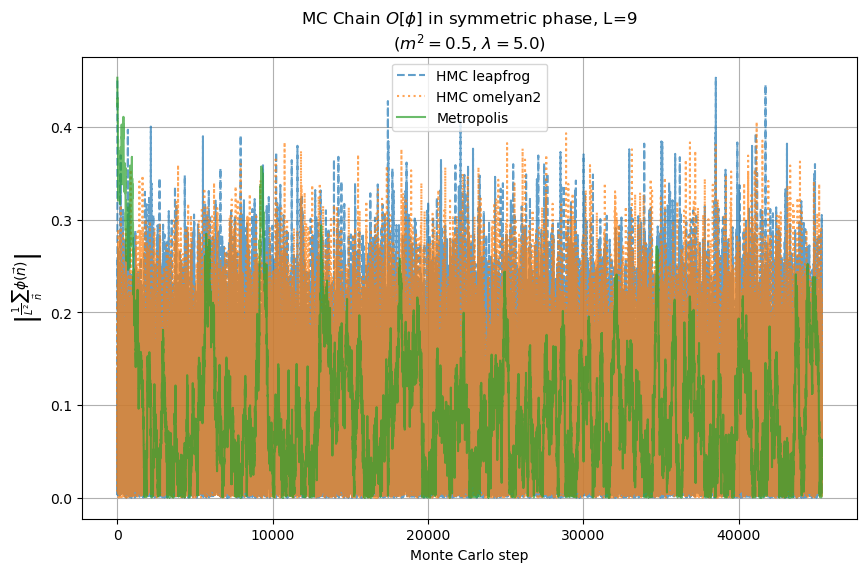

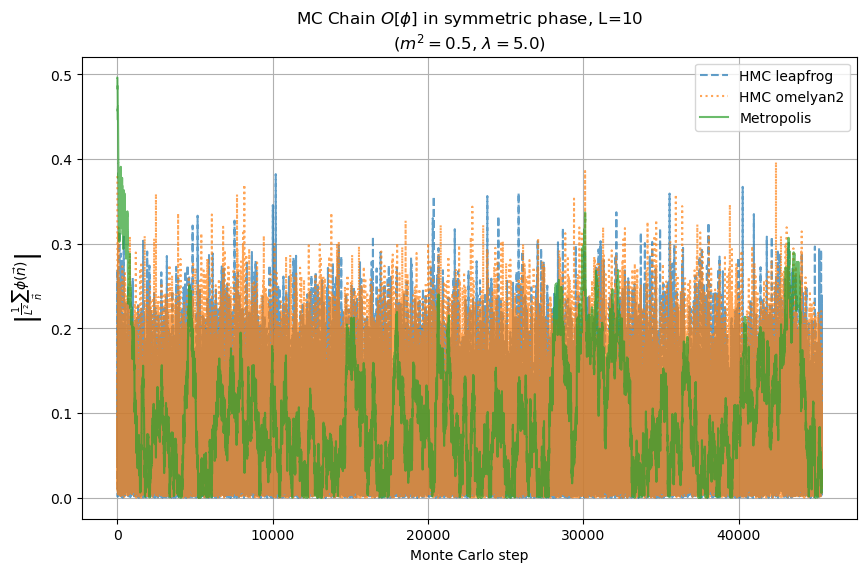

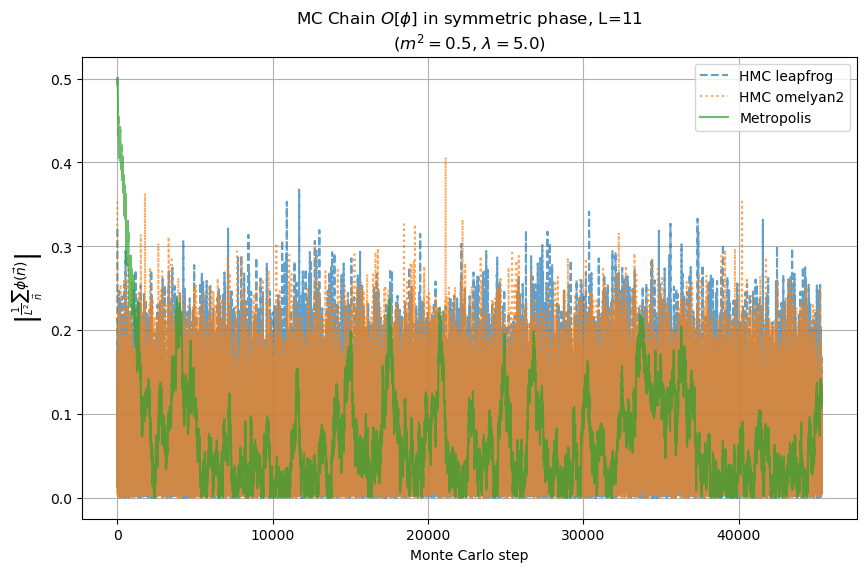

In [18]:
import numpy as np
import matplotlib.pyplot as plt

L_vals = list(range(4, 12))

phases = {
    "broken": {"m2": -0.5, "lam": 5.0},
    "symmetric": {"m2": +0.5, "lam": 5.0},
}

algorithms = ["Metropolis", "HMC_leapfrog", "HMC_omelyan2"]

for phase_name, params in phases.items():
    m2 = params["m2"]
    lam = params["lam"]

    for L in L_vals:
        filename = (
            f"observable_measurements_{phase_name}_"
            f"m2{m2}_lam{lam}_L{L}_all_algs.npz"
        )
        data = np.load(filename)

        plt.figure(figsize=(10, 6))

        plt.plot(
            data[f"HMC_leapfrog_L{L}"],
            linestyle="--",
            label="HMC leapfrog",
            alpha=0.7,
        )

        plt.plot(
            data[f"HMC_omelyan2_L{L}"],
            linestyle=":",
            label="HMC omelyan2",
            alpha=0.7,
        )
        plt.plot(
            data[f"Metropolis_L{L}"],
            label="Metropolis",
            alpha=0.7,
        )
        plt.title(
            f"MC Chain $O[\\phi]$ in {phase_name} phase, L={L}\n"
            rf"($m^2={m2}$, $\lambda={lam}$)"
        )
        plt.xlabel("Monte Carlo step")
        plt.ylabel(r"$\left| \frac{1}{L^2} \sum_{\vec n} \phi(\vec n) \right|$")
        plt.legend()
        plt.grid(True)
        plt.show()
#these plots are not very useful and quite ugly

### Measuring run time (Python)

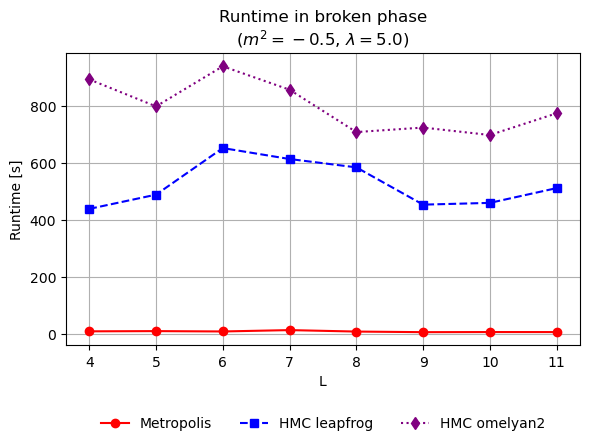

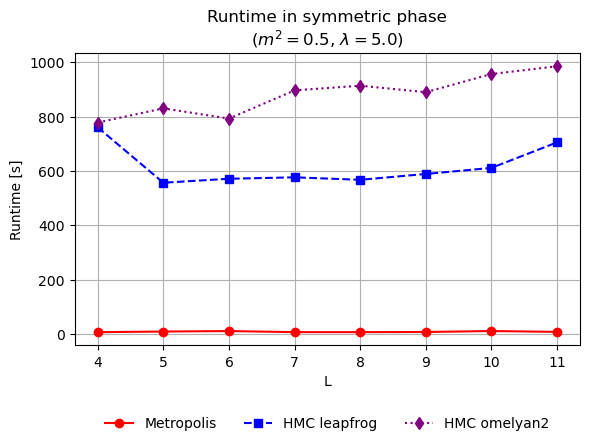

In [21]:
import numpy as np
import matplotlib.pyplot as plt

L_vals = list(range(4, 12))

phases = {
    "broken": {"m2": -0.5, "lam": 5.0},
    "symmetric": {"m2": +0.5, "lam": 5.0},
}

algorithms = ["Metropolis", "HMC_leapfrog", "HMC_omelyan2"]

colors = ["red", "blue", "purple"]
for phase_name, params in phases.items():
    m2 = params["m2"]
    lam = params["lam"]

    runtimes = [
        np.load(
            f"observable_runtimes_{phase_name}_"
            f"m2{m2}_lam{lam}_L{L}_all_algs.npz"
        )
        for L in L_vals
    ]

    t_met = [r[f"Metropolis_L{L}"] for r, L in zip(runtimes, L_vals)]
    t_hmc_lf = [r[f"HMC_leapfrog_L{L}"] for r, L in zip(runtimes, L_vals)]
    t_hmc_om = [r[f"HMC_omelyan2_L{L}"] for r, L in zip(runtimes, L_vals)]

    plt.figure(figsize=(6, 5))
    plt.plot(L_vals, t_met, "o-", label="Metropolis", color = colors[0])
    plt.plot(L_vals, t_hmc_lf, "s--", label="HMC leapfrog", color = colors[1])
    plt.plot(L_vals, t_hmc_om, "d:", label="HMC omelyan2", color = colors[2])

    plt.xlabel("L")
    plt.ylabel("Runtime [s]")
    plt.title(
        f"Runtime in {phase_name} phase\n"
        rf"($m^2={m2}$, $\lambda={lam}$)"
    )
    plt.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, -0.2),
        ncol=3,
        frameon=False
    )
    plt.tight_layout(rect=[0, 0.05, 1, 1])
    plt.grid(True)
    plt.show()


### Error and autocorrelation (Python)

Applying binning:   0%|          | 0/100 [00:00<?, ?it/s]

Applying binning:   0%|          | 0/100 [00:00<?, ?it/s]

Applying binning:   0%|          | 0/100 [00:00<?, ?it/s]

Applying binning:   0%|          | 0/100 [00:00<?, ?it/s]

Applying binning:   0%|          | 0/100 [00:00<?, ?it/s]

...

Applying binning:   0%|          | 0/100 [00:00<?, ?it/s]

Applying binning:   0%|          | 0/100 [00:00<?, ?it/s]

Applying binning:   0%|          | 0/100 [00:00<?, ?it/s]

Applying binning:   0%|          | 0/100 [00:00<?, ?it/s]

Applying binning:   0%|          | 0/100 [00:00<?, ?it/s]

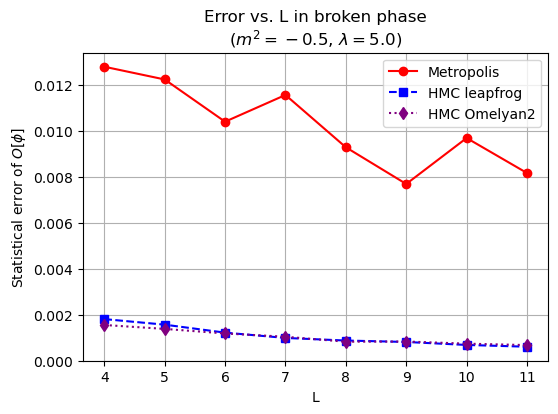

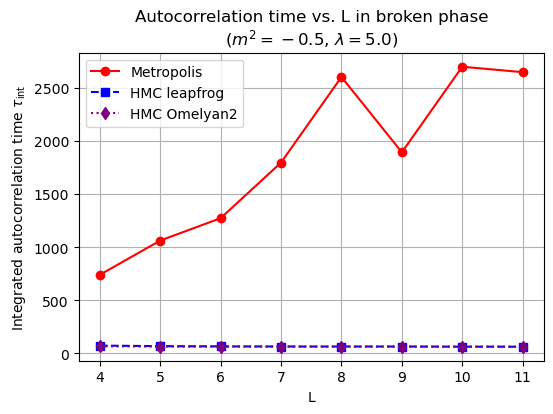

Applying binning:   0%|          | 0/100 [00:00<?, ?it/s]

Applying binning:   0%|          | 0/100 [00:00<?, ?it/s]

Applying binning:   0%|          | 0/100 [00:00<?, ?it/s]

Applying binning:   0%|          | 0/100 [00:00<?, ?it/s]

Applying binning:   0%|          | 0/100 [00:00<?, ?it/s]

...

Applying binning:   0%|          | 0/100 [00:00<?, ?it/s]

Applying binning:   0%|          | 0/100 [00:00<?, ?it/s]

Applying binning:   0%|          | 0/100 [00:00<?, ?it/s]

Applying binning:   0%|          | 0/100 [00:00<?, ?it/s]

Applying binning:   0%|          | 0/100 [00:00<?, ?it/s]

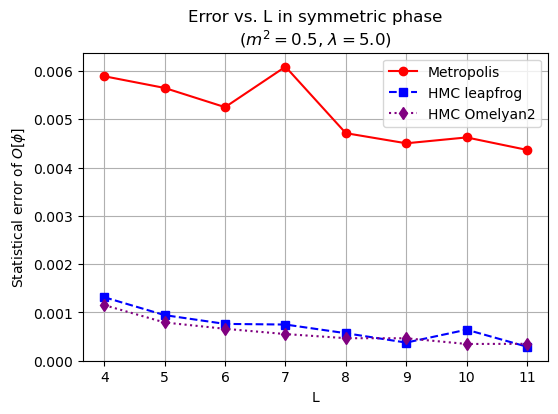

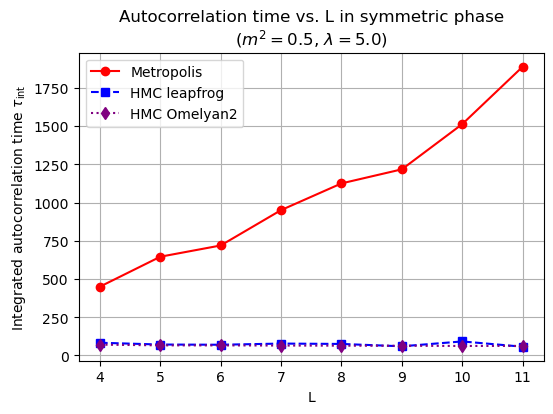

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from stats.analysis import apply_binning, integrated_autocorr_time, autocorrelation

L_vals = list(range(4, 12))

phases = {
    "broken": {"m2": -0.5, "lam": 5.0},
    "symmetric": {"m2": +0.5, "lam": 5.0},
}

algorithms = ["Metropolis", "HMC_leapfrog", "HMC_omelyan2"]
colors = ["red", "blue", "purple"]

for phase_name, params in phases.items():
    m2 = params["m2"]
    lam = params["lam"]

    err = {alg: [] for alg in algorithms}
    tau = {alg: [] for alg in algorithms}

    for L in L_vals:
        data = np.load(
            f"observable_measurements_{phase_name}_"
            f"m2{m2}_lam{lam}_L{L}_all_algs.npz"
        )

        for alg in algorithms:
            series = data[f"{alg}_L{L}"]

            bins, errs = apply_binning(series)
            err[alg].append(errs[-1])

            tau[alg].append(
                integrated_autocorr_time(autocorrelation(series))
            )

    # errors
    plt.figure(figsize=(6, 4))
    plt.plot(L_vals, err["Metropolis"], "o-", label="Metropolis", color = colors[0])
    plt.plot(L_vals, err["HMC_leapfrog"], "s--", label="HMC leapfrog", color = colors[1])
    plt.plot(L_vals, err["HMC_omelyan2"], "d:", label="HMC Omelyan2", color = colors[2])

    plt.xlabel("L")
    plt.ylabel("Statistical error of $O[\\phi]$")
    plt.title(
        f"Error vs. L in {phase_name} phase\n"
        rf"($m^2={m2}$, $\lambda={lam}$)"
    )
    plt.legend()
    plt.grid(True)
    plt.show()

    # autocorrelation
    plt.figure(figsize=(6, 4))
    plt.plot(L_vals, tau["Metropolis"], "o-", label="Metropolis", color = colors[0])
    plt.plot(L_vals, tau["HMC_leapfrog"], "s--", label="HMC leapfrog", color = colors[1])
    plt.plot(L_vals, tau["HMC_omelyan2"], "d:", label="HMC Omelyan2", color = colors[2])

    plt.xlabel("L")
    plt.ylabel(r"Integrated autocorrelation time $\tau_{\mathrm{int}}$")
    plt.title(
        f"Autocorrelation time vs. L in {phase_name} phase\n"
        rf"($m^2={m2}$, $\lambda={lam}$)"
    )
    plt.legend()
    plt.grid(True)
    plt.show()


## Rust

### Tuning Rust (use same parameters as in Python)

# Acceptance rate vs. L (constant width)

[70.0, 57.49999999999999, 52.5, 42.5, 41.5, 42.5, 26.0, 25.5, 22.0, 15.5]
[92.0, 87.0, 89.5, 85.5, 81.5, 81.5, 84.5, 85.5, 83.5, 76.5]
[92.0, 89.0, 91.5, 87.0, 87.5, 84.0, 78.0, 79.0, 79.5, 77.0]


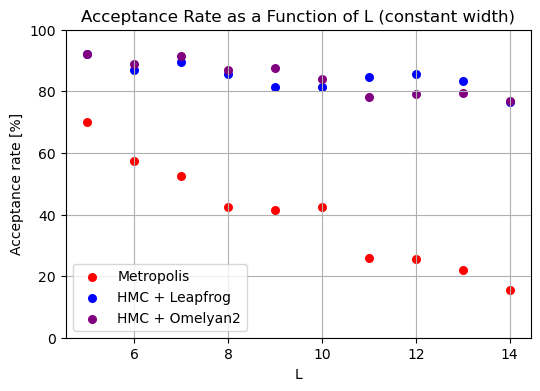

# Acceptance rate vs. L (adapted step size)

[53.0, 45.0, 50.0, 51.0, 55.00000000000001, 50.5, 55.00000000000001, 49.5, 51.0, 50.5]
[82.0, 87.0, 87.5, 88.5, 86.0, 89.5, 92.5, 94.5, 93.0, 93.5]
[93.0, 93.5, 91.5, 85.0, 87.5, 84.5, 87.0, 80.0, 77.0, 72.5]


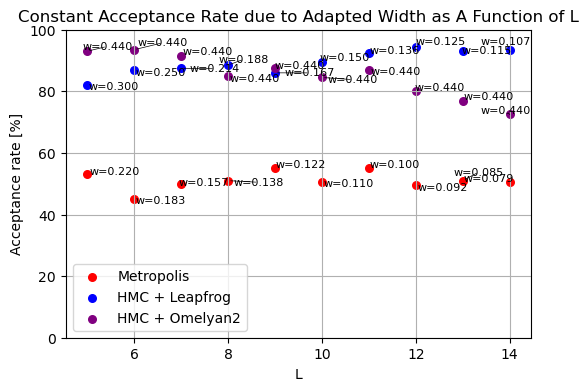

In [16]:
from IPython.display import display, Markdown
import numpy as np
import matplotlib.pyplot as plt
from adjustText import adjust_text
import lattice_rs

# Parameters
L_vals = list(range(5, 15))
m2 = -0.5
lam = 5.0

# Storage of results
results = {
    "Metropolis": {"const": [], "adapt": [], "widths": []},
    "HMC + Leapfrog": {"const": [], "adapt": [], "widths": []},
    "HMC + Omelyan2": {"const": [], "adapt": [], "widths": []},
}

colors = ["red", "blue", "purple"]
# Loop over L
for L in L_vals:
    # RNG per L for reproducibility
    rng = np.random.default_rng(42 + L)
    phi_field = rng.random(L**2).tolist()  # flattened for Rust

    # --- Metropolis ---
    w_const = 0.14
    w_adapt = 1.1 / L
    results["Metropolis"]["widths"].append(w_adapt)

    # Constant width
    sim = lattice_rs.MetropolisSim(phi_field, L=L, mass2=m2, lambda_=lam, eps=w_const)
    for _ in range(200):
        sim.update()
    results["Metropolis"]["const"].append(np.mean(sim.accepted_history) * 100)

    # Adapted width
    sim = lattice_rs.MetropolisSim(phi_field, L=L, mass2=m2, lambda_=lam, eps=w_adapt)
    for _ in range(200):
        sim.update()
    results["Metropolis"]["adapt"].append(np.mean(sim.accepted_history) * 100)

    # --- HMC + Leapfrog ---
    w_const = 0.2
    w_adapt = 1.5 / L
    results["HMC + Leapfrog"]["widths"].append(w_adapt)

    # Constant step size
    sim = lattice_rs.HMCSim(phi0=phi_field, L=L, mass2=m2, lambda_=lam,
                             eps=w_const, steps=100, integrator="leapfrog")
    for _ in range(200):
        sim.update()
    results["HMC + Leapfrog"]["const"].append(np.mean(sim.accepted_history) * 100)

    # Adapted step size
    sim = lattice_rs.HMCSim(phi0=phi_field, L=L, mass2=m2, lambda_=lam,
                             eps=w_adapt, steps=100, integrator="leapfrog")
    for _ in range(200):
        sim.update()
    results["HMC + Leapfrog"]["adapt"].append(np.mean(sim.accepted_history) * 100)

    # --- HMC + Omelyan2 ---
    w_const = 0.44
    w_adapt = 0.44
    results["HMC + Omelyan2"]["widths"].append(w_adapt)

    # Prepare a sequence of momenta for reproducibility
    pi_rng = np.random.default_rng(1234 + L)
    pi_sequence = [pi_rng.standard_normal(L*L).tolist() for _ in range(200)]

    # Constant step size
    sim = lattice_rs.HMCSim(phi0=phi_field, L=L, mass2=m2, lambda_=lam,
                             eps=w_const, steps=100, integrator="omelyan2")
    for pi_step in pi_sequence:
        sim.update(pi_override=pi_step)
    results["HMC + Omelyan2"]["const"].append(np.mean(sim.accepted_history) * 100)

    # Adapted step size
    pi_sequence = [pi_rng.standard_normal(L*L).tolist() for _ in range(200)]
    sim = lattice_rs.HMCSim(phi0=phi_field, L=L, mass2=m2, lambda_=lam,
                             eps=w_adapt, steps=100, integrator="omelyan2")
    for pi_step in pi_sequence:
        sim.update(pi_override=pi_step)
    results["HMC + Omelyan2"]["adapt"].append(np.mean(sim.accepted_history) * 100)


#Plot 1: Constant width
display(Markdown("# Acceptance rate vs. L (constant width)"))

plt.figure(figsize=(6, 4))
for (name, data), c in zip(results.items(), colors):
    plt.scatter(L_vals, data["const"], s=30, label=name, color = c)
    print(data["const"])
plt.xlabel("L")
plt.ylabel("Acceptance rate [%]")
plt.title("Acceptance Rate as a Function of L (constant width)")
plt.ylim(0, 100)
plt.grid(True)
plt.legend()
plt.show()


#Plot 2: Adapted width
display(Markdown("# Acceptance rate vs. L (adapted step size)"))

plt.figure(figsize=(6, 4))
texts = []

for (name, data), c in zip(results.items(), colors):
    plt.scatter(L_vals, data["adapt"], s=30, label=name, color = c)
    for L, acc, w in zip(L_vals, data["adapt"], data["widths"]):
        texts.append(plt.text(L, acc, f"w={w:.3f}", fontsize=8))
    print(data["adapt"])
adjust_text(
    texts,
    arrowprops=dict(arrowstyle="-", lw=0.5),
    expand_points=(1.2, 1.2),
    expand_text=(1.2, 1.2),
)

plt.xlabel("L")
plt.ylabel("Acceptance rate [%]")
plt.title("Constant Acceptance Rate due to Adapted Width as A Function of L")
plt.ylim(0, 100)
plt.grid(True)
plt.legend()
plt.show()


### Generating data with rust

In [40]:
import numpy as np
import time
from tqdm import tqdm
import lattice_rs

L_vals = list(range(4, 12))
num_steps = 45_360 #highly composite number
rng = np.random.default_rng(42)

algorithms = {
    "Metropolis": {
        "type": "metropolis",
        "width_factor": lambda L: 1.1 / L,
    },
    "HMC_leapfrog": {
        "type": "hmc",
        "integrator": "leapfrog",
        "width_factor": lambda L: 1.5 / L,
    },
    "HMC_omelyan2": {
        "type": "hmc",
        "integrator": "omelyan2",
        "width_factor": lambda L: 0.44,
    },
}

phases = {
    "broken": {"m2": -0.5, "lam": 5.0},
    "symmetric": {"m2": +0.5, "lam": 5.0},
}


for phase_name, params in phases.items():
    m2 = params["m2"]
    lam = params["lam"]

    print(f"\n{phase_name}")

    for L in tqdm(L_vals, desc=f"{phase_name} phase"):
        phi0 = rng.random(L * L).tolist()

        results = {}
        runtimes = {}
        acceptance_rates = {}

        for alg_name, alg in algorithms.items():
            width = alg["width_factor"](L)

            t0 = time.perf_counter()
            
            #metropolis
            if alg["type"] == "metropolis":
                sim = lattice_rs.MetropolisSim(
                    phi0=phi0,
                    L=L,
                    mass2=m2,
                    lambda_=lam,
                    eps=width,
                )

                for _ in range(num_steps):
                    sim.update()

            #HMC, both versions
            elif alg["type"] == "hmc":
                sim = lattice_rs.HMCSim(
                    phi0=phi0,
                    L=L,
                    mass2=m2,
                    lambda_=lam,
                    eps=width,
                    steps=100,
                    integrator=alg["integrator"],
                )

                for _ in range(num_steps):
                    sim.update()

            else:
                raise ValueError("Unknown algorithm")

            t1 = time.perf_counter()

            acc = np.mean(sim.accepted_history)

            print(
                f"{alg_name:15s} | "
                f"L={L:2d} | "
                f"eps={width:.4f} | "
                f"acceptance={acc:.3f}"
            )

            measurements = []

            for _ in range(num_steps):
                sim.update()
                measurements.append(np.mean(sim.phi))

            results[f"{alg_name}_L{L}"] = np.array(measurements, dtype=np.float32)

            runtimes[f"{alg_name}_L{L}"] = t1 - t0
            acceptance_rates[f"{alg_name}_L{L}"] = acc

        np.savez(
            f"observable_results_{phase_name}_L{L}_rust.npz",
            **results
        )
        np.savez(
            f"runtimes_{phase_name}_L{L}_rust.npz",
            **runtimes
        )
        np.savez(
            f"acceptance_{phase_name}_L{L}_rust.npz",
            **acceptance_rates
        )



broken


broken phase:   0%|          | 0/8 [00:00<?, ?it/s]

Metropolis      | L= 4 | eps=0.2750 | acceptance=0.500
HMC_leapfrog    | L= 4 | eps=0.3750 | acceptance=0.768
HMC_omelyan2    | L= 4 | eps=0.4400 | acceptance=0.939


broken phase:  12%|█▎        | 1/8 [01:40<11:44, 100.60s/it]

Metropolis      | L= 5 | eps=0.2200 | acceptance=0.508
HMC_leapfrog    | L= 5 | eps=0.3000 | acceptance=0.832
HMC_omelyan2    | L= 5 | eps=0.4400 | acceptance=0.916


...

symmetric phase:  75%|███████▌  | 6/8 [23:42<10:10, 305.22s/it]

Metropolis      | L=10 | eps=0.1100 | acceptance=0.471
HMC_leapfrog    | L=10 | eps=0.1500 | acceptance=0.920
HMC_omelyan2    | L=10 | eps=0.4400 | acceptance=0.861


symmetric phase:  88%|████████▊ | 7/8 [31:48<06:04, 364.28s/it]

Metropolis      | L=11 | eps=0.1000 | acceptance=0.472
HMC_leapfrog    | L=11 | eps=0.1364 | acceptance=0.922
HMC_omelyan2    | L=11 | eps=0.4400 | acceptance=0.845


symmetric phase: 100%|██████████| 8/8 [41:04<00:00, 308.02s/it]


### Measuring runtime (Rust)

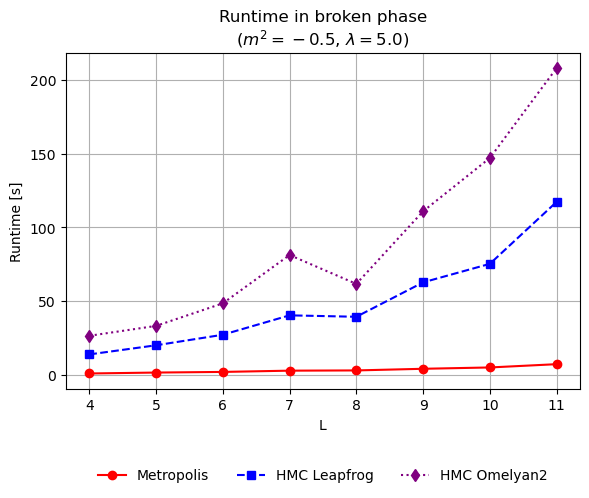

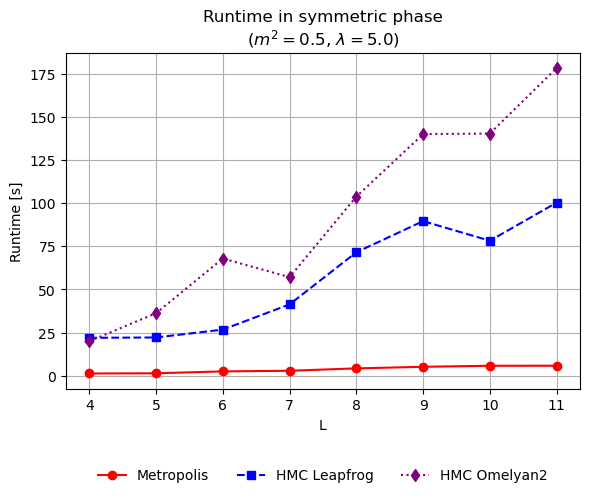

In [49]:
import numpy as np
import matplotlib.pyplot as plt

L_vals = list(range(4, 12))

phases = {
    "broken": {"m2": -0.5, "lam": 5.0},
    "symmetric": {"m2": +0.5, "lam": 5.0},
}

colors = ["red", "blue", "purple"]

for phase_name, params in phases.items():
    m2 = params["m2"]
    lam = params["lam"]

    runtimes = [
        np.load(
            f"runtimes_{phase_name}_L{L}_rust.npz"
        )
        for L in L_vals
    ]

    t_met = [r[f"Metropolis_L{L}"] for r, L in zip(runtimes, L_vals)]
    t_hmc_lf = [r[f"HMC_leapfrog_L{L}"] for r, L in zip(runtimes, L_vals)]
    t_hmc_om = [r[f"HMC_omelyan2_L{L}"] for r, L in zip(runtimes, L_vals)]

    plt.figure(figsize=(6, 5))
    plt.plot(L_vals, t_met, "o-", label="Metropolis", color = colors[0])
    plt.plot(L_vals, t_hmc_lf, "s--", label="HMC Leapfrog", color = colors[1])
    plt.plot(L_vals, t_hmc_om, "d:", label="HMC Omelyan2", color = colors[2])

    plt.xlabel("L")
    plt.ylabel("Runtime [s]")
    plt.title(
        f"Runtime in {phase_name} phase\n"
        rf"($m^2={m2}$, $\lambda={lam}$)"
    )
    plt.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, -0.2),
        ncol=3,
        frameon=False
    )
    plt.tight_layout(rect=[0, 0.05, 1, 1])
    plt.grid(True)
    plt.tight_layout()
    plt.show()


### Error and autocorrelation (Rust)

Applying binning:   0%|          | 0/100 [00:00<?, ?it/s]

Applying binning:   0%|          | 0/100 [00:00<?, ?it/s]

Applying binning:   0%|          | 0/100 [00:00<?, ?it/s]

Applying binning:   0%|          | 0/100 [00:00<?, ?it/s]

Applying binning:   0%|          | 0/100 [00:00<?, ?it/s]

...

Applying binning:   0%|          | 0/100 [00:00<?, ?it/s]

Applying binning:   0%|          | 0/100 [00:00<?, ?it/s]

Applying binning:   0%|          | 0/100 [00:00<?, ?it/s]

Applying binning:   0%|          | 0/100 [00:00<?, ?it/s]

Applying binning:   0%|          | 0/100 [00:00<?, ?it/s]

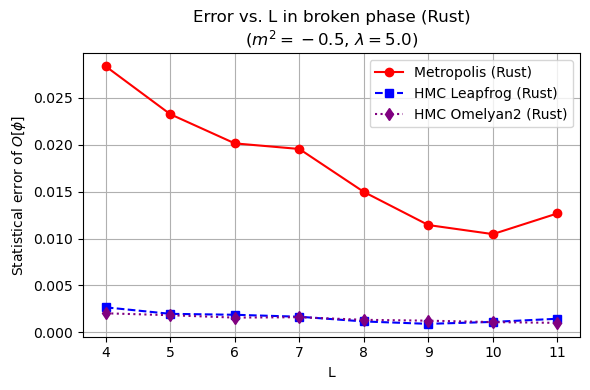

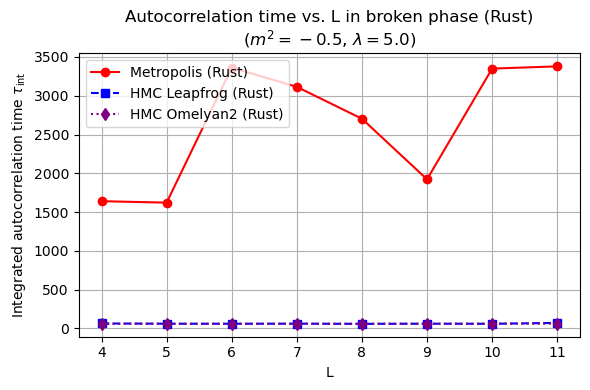

Applying binning:   0%|          | 0/100 [00:00<?, ?it/s]

Applying binning:   0%|          | 0/100 [00:00<?, ?it/s]

Applying binning:   0%|          | 0/100 [00:00<?, ?it/s]

Applying binning:   0%|          | 0/100 [00:00<?, ?it/s]

Applying binning:   0%|          | 0/100 [00:00<?, ?it/s]

...

Applying binning:   0%|          | 0/100 [00:00<?, ?it/s]

Applying binning:   0%|          | 0/100 [00:00<?, ?it/s]

Applying binning:   0%|          | 0/100 [00:00<?, ?it/s]

Applying binning:   0%|          | 0/100 [00:00<?, ?it/s]

Applying binning:   0%|          | 0/100 [00:00<?, ?it/s]

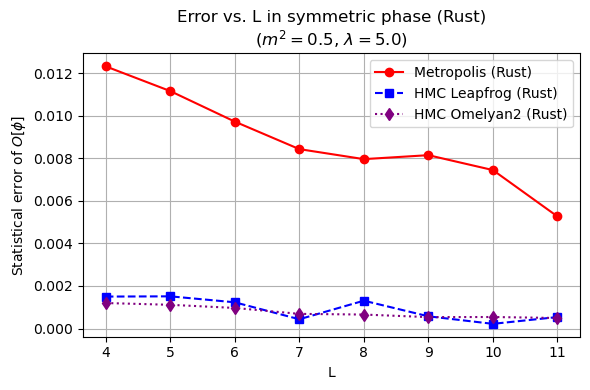

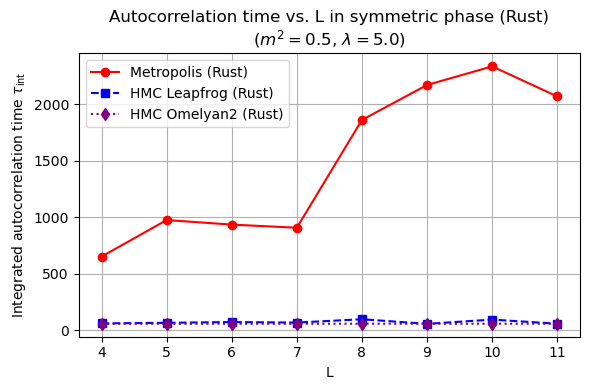

In [50]:
import numpy as np
import matplotlib.pyplot as plt
from stats.analysis import apply_binning, integrated_autocorr_time, autocorrelation

L_vals = list(range(4, 12))

phases = {
    "broken": {"m2": -0.5, "lam": 5.0},
    "symmetric": {"m2": +0.5, "lam": 5.0},
}

algorithms = ["Metropolis", "HMC_leapfrog", "HMC_omelyan2"]

colors = ["red", "blue", "purple"]
for phase_name, params in phases.items():
    m2 = params["m2"]
    lam = params["lam"]

    err = {alg: [] for alg in algorithms}
    tau = {alg: [] for alg in algorithms}

    for L in L_vals:
        data = np.load(
            f"observable_results_{phase_name}_L{L}_rust.npz"
        )

        for alg in algorithms:
            series = data[f"{alg}_L{L}"]
            bins, errs = apply_binning(series)
            err[alg].append(errs[-1])

            tau[alg].append(
                integrated_autocorr_time(
                    autocorrelation(series)
                )
            )

    # errors
    plt.figure(figsize=(6, 4))
    plt.plot(L_vals, err["Metropolis"], "o-", label="Metropolis (Rust)", color = colors[0])
    plt.plot(L_vals, err["HMC_leapfrog"], "s--", label="HMC Leapfrog (Rust)", color = colors[1])
    plt.plot(L_vals, err["HMC_omelyan2"], "d:", label="HMC Omelyan2 (Rust)", color = colors[2])

    plt.xlabel("L")
    plt.ylabel("Statistical error of $O[\\phi]$")
    plt.title(
        f"Error vs. L in {phase_name} phase (Rust)\n"
        rf"($m^2={m2}$, $\lambda={lam}$)"
    )
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # autocorrelation
    plt.figure(figsize=(6, 4))
    plt.plot(L_vals, tau["Metropolis"], "o-", label="Metropolis (Rust)", color = colors[0])
    plt.plot(L_vals, tau["HMC_leapfrog"], "s--", label="HMC Leapfrog (Rust)", color = colors[1])
    plt.plot(L_vals, tau["HMC_omelyan2"], "d:", label="HMC Omelyan2 (Rust)", color = colors[2])

    plt.xlabel("L")
    plt.ylabel(r"Integrated autocorrelation time $\tau_{\mathrm{int}}$")
    plt.title(
        f"Autocorrelation time vs. L in {phase_name} phase (Rust)\n"
        rf"($m^2={m2}$, $\lambda={lam}$)"
    )
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


## Topological fun stuff (Rust only)

broken


broken phase:  12%|█▎        | 1/8 [00:09<01:08,  9.77s/it]

L=4, Q_R=0.0086 ± 0.0033, acceptance PBC=0.507, APBC=0.514


broken phase:  25%|██▌       | 2/8 [00:19<00:57,  9.64s/it]

L=5, Q_R=-0.0860 ± 0.0034, acceptance PBC=0.507, APBC=0.511


...

L=9, Q_R=0.2496 ± 0.0034, acceptance PBC=0.506, APBC=0.505


broken phase:  88%|████████▊ | 7/8 [01:55<00:19, 19.16s/it]

L=10, Q_R=0.1697 ± 0.0031, acceptance PBC=0.506, APBC=0.507


broken phase: 100%|██████████| 8/8 [02:22<00:00, 17.78s/it]

L=11, Q_R=-0.1353 ± 0.0032, acceptance PBC=0.504, APBC=0.506


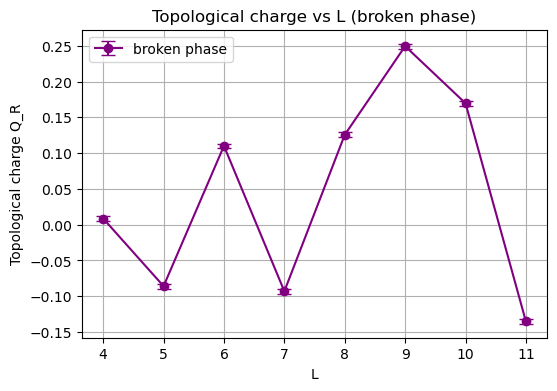

symmetric


symmetric phase:  12%|█▎        | 1/8 [00:07<00:54,  7.76s/it]

L=4, Q_R=-0.0272 ± 0.0035, acceptance PBC=0.481, APBC=0.479


symmetric phase:  25%|██▌       | 2/8 [00:17<00:52,  8.75s/it]

L=5, Q_R=-0.0147 ± 0.0032, acceptance PBC=0.475, APBC=0.477


...

L=9, Q_R=-0.0763 ± 0.0032, acceptance PBC=0.473, APBC=0.470


symmetric phase:  88%|████████▊ | 7/8 [01:42<00:18, 18.14s/it]

L=10, Q_R=0.0768 ± 0.0032, acceptance PBC=0.473, APBC=0.475


symmetric phase: 100%|██████████| 8/8 [02:09<00:00, 16.23s/it]

L=11, Q_R=0.0567 ± 0.0032, acceptance PBC=0.474, APBC=0.474


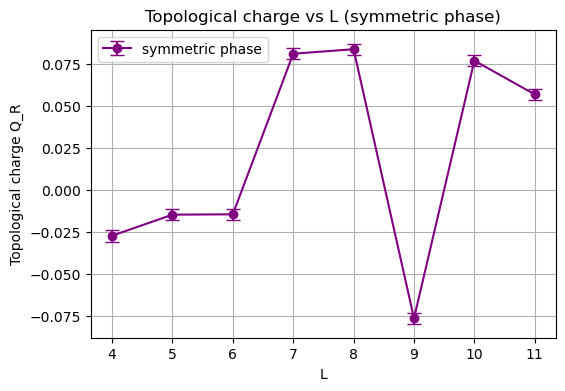

In [7]:
import numpy as np
import time
from tqdm import tqdm
import lattice_rs
import matplotlib.pyplot as plt
from lattice_rs import BoundaryCondition
import physics.observables as observables

L_vals = list(range(4, 12))
num_steps = 83160 
rng = np.random.default_rng(42)

width_factor = lambda L: 1.1 / L

phases = {
    "broken": {"m2": -0.5, "lam": 5.0},
    "symmetric": {"m2": +0.5, "lam": 5.0},
}

# Helper 
def run_metropolis(phi0, L, m2, lam, width, bc):
    """Run Metropolis simulation and return samples + acceptance."""
    sim = lattice_rs.MetropolisSim(
        phi0=phi0,
        L=L,
        mass2=m2,
        lambda_=lam,
        eps=width,
        bc=bc
    )
    samples = []
    for _ in range(num_steps):
        sim.update()
        samples.append(sim.phi.copy())

    return np.array(samples, dtype=np.float32), np.mean(sim.accepted_history)


for phase_name, params in phases.items():
    m2 = params["m2"]
    lam = params["lam"]

    print(phase_name)

    Q_R_means = []  
    Q_R_errors = [] 

    for L in tqdm(L_vals, desc=f"{phase_name} phase"):
        phi0 = rng.random(L * L).tolist() 
        width = width_factor(L)

        samples_all = {}
        acceptance_rates = {}

        for bc in [BoundaryCondition.PBC, BoundaryCondition.APBC]:
            samples, acc = run_metropolis(
                phi0=phi0,
                L=L,
                m2=m2,
                lam=lam,
                width=width,
                bc=bc
            )
            bc_str = "PBC" if bc == lattice_rs.BoundaryCondition.PBC else "APBC"
            key_samples = f"Metropolis_L{L}_{bc_str}"
            samples_all[key_samples] = samples
            acceptance_rates[key_samples] = acc

        phi_samples_pbc = samples_all[f"Metropolis_L{L}_PBC"]
        phi_samples_apbc = samples_all[f"Metropolis_L{L}_APBC"]
        
        # Compute Q_R for each sample 
        Q_R_values = []
        for i in range(num_steps):
            Q_R = observables.topological_charge_QR(
                phi_samples_pbc[i:i+1],  # shape (1, L, L)
                phi_samples_apbc[i:i+1],
                spatial_axis=0
            )
            Q_R_values.append(Q_R)
        
        Q_R_values = np.array(Q_R_values)
        
        Q_mean = np.mean(Q_R_values)
        Q_error = np.std(Q_R_values) / np.sqrt(len(Q_R_values))
        
        Q_R_means.append(Q_mean)
        Q_R_errors.append(Q_error)

        print(f"L={L}, Q_R={Q_mean:.4f} ± {Q_error:.4f}, "
              f"acceptance PBC={acceptance_rates[f'Metropolis_L{L}_PBC']:.3f}, "
              f"APBC={acceptance_rates[f'Metropolis_L{L}_APBC']:.3f}")

    plt.figure(figsize=(6, 4))
    
    plt.errorbar(L_vals, Q_R_means, yerr=Q_R_errors, 
                 marker='o', color='purple', 
                 capsize=5, label=f'{phase_name} phase')
    
    plt.xlabel("L")
    plt.ylabel("Topological charge Q_R")
    plt.title(f"Topological charge vs L ({phase_name} phase)")
    plt.grid(True)
    plt.legend()
    plt.show()

# Tests: Comparing Rust and Python

In [45]:
import lattice_rs
import numpy as np
from physics.actions import phi4_action, BoundaryCondition

def test_actions():
    L = 4
    phi = np.ones((L, L))
    mass2 = -0.5
    lamb = 5.0
    
    # Use the exposed enum
    RustBC = lattice_rs.BoundaryCondition
    
    # PBC
    rust_action = lattice_rs.phi4_action(phi.flatten().tolist(), L, mass2, lamb, RustBC.PBC)
    python_action = phi4_action(phi, mass2, lamb, BoundaryCondition.PBC)
    print(f"PBC: Rust={rust_action:.6f}, Python={python_action:.6f}")
    
    # test APBC
    rust_action = lattice_rs.phi4_action(phi.flatten().tolist(), L, mass2, lamb, RustBC.APBC)
    python_action = phi4_action(phi, mass2, lamb, BoundaryCondition.APBC)
    print(f"APBC: Rust={rust_action:.6f}, Python={python_action:.6f}")

test_actions()

PBC: Rust=-0.666667, Python=-0.666667
APBC: Rust=7.333333, Python=7.333333


In [46]:
import numpy as np
import lattice_rs
from algorithms.integrators import leapfrog, omelyan2
from physics.actions import gradient_phi4_action, BoundaryCondition

# Same seed for reproducibility
np.random.seed(42)
L = 5
mass2 = -0.5
lam = 5.0
eps = 0.1

phi_flat = np.random.random(L*L)
pi_flat = np.random.random(L*L)

phi_2d = phi_flat.reshape(L, L)
pi_2d = pi_flat.reshape(L, L)

# Test Leapfrog
print("Testing Leapfrog")
rust_phi, rust_pi = lattice_rs.test_leapfrog(
    phi_flat.tolist(), pi_flat.tolist(), L, mass2, lam, eps
)
python_phi, python_pi = leapfrog(
    phi_2d, pi_2d, eps,
    grad_action=gradient_phi4_action,
    grad_kwargs=dict(mass2=mass2, lamb=lam, bc=BoundaryCondition.PBC)
)

print("Python phi[:5]:", python_phi.flatten()[:5])
print("Rust phi[:5]:  ", rust_phi[:5])
print("Difference:    ", python_phi.flatten()[:5] - rust_phi[:5])

# Omelyan2
print("\nTesting Omelyan2")
rust_phi2, rust_pi2 = lattice_rs.test_omelyan2(
    phi_flat.tolist(), pi_flat.tolist(), L, mass2, lam, eps
)
python_phi2, python_pi2 = omelyan2(
    phi_2d, pi_2d, eps,
    grad_action=gradient_phi4_action,
    grad_kwargs=dict(mass2=mass2, lamb=lam, bc=BoundaryCondition.PBC)
)

print("Python phi[:5]:", python_phi2.flatten()[:5])
print("Rust phi[:5]:  ", rust_phi2[:5])
print("Difference:    ", python_phi2.flatten()[:5] - rust_phi2[:5])

Testing Leapfrog
Python phi[:5]: [0.45565725 0.95698428 0.78251174 0.65580689 0.16860424]
Rust phi[:5]:   [0.45565724554777104, 0.9569842817679103, 0.782511736971852, 0.6558068881299344, 0.1686042372608809]
Difference:     [0. 0. 0. 0. 0.]

Testing Omelyan2
Python phi[:5]: [0.45541029 0.95714161 0.7823289  0.65573011 0.1689445 ]
Rust phi[:5]:   [0.4554102878418396, 0.9571416079682444, 0.7823288981943246, 0.6557301135833241, 0.1689444975078973]
Difference:     [0. 0. 0. 0. 0.]


In [47]:
import numpy as np
import lattice_rs
from physics.actions import gradient_phi4_action, BoundaryCondition

L = 5
phi_test = np.random.random(L*L).tolist()
pi_test = np.random.random(L*L).tolist()
mass2 = -0.5
lam = 5.0
eps = 0.1

sim_rust = lattice_rs.HMCSim(
    phi0=phi_test,
    L=L,
    mass2=mass2,
    lambda_=lam,
    eps=eps,
    steps=1,
    integrator="omelyan2",
)

sim_rust.update(pi_override=pi_test)#same as in Python

from algorithms.integrators import leapfrog, omelyan2
phi_np = np.array(phi_test).reshape(L, L)
pi_np = np.array(pi_test).reshape(L, L)

phi_new_py, pi_new_py = omelyan2(
    phi_np, pi_np, eps,
    grad_action=gradient_phi4_action,
    grad_kwargs=dict(mass2=mass2, lamb=lam, bc=BoundaryCondition.PBC)
)

print("Python phi after 1 step:", phi_new_py.flatten()[:5])
print("Rust phi after 1 step:", sim_rust.phi[:5])


Python phi after 1 step: [1.03674578 0.84744694 0.9366298  0.92377506 0.61275675]
Rust phi after 1 step: [1.0367457804507514, 0.8474469386001762, 0.9366298027762556, 0.9237750550047376, 0.6127567459237997]


In [48]:
L = 3
phi_simple = np.arange(L*L).reshape(L, L).astype(float)
pi_simple = np.ones((L, L))
grad_py = gradient_phi4_action(phi_simple, -0.5, 5.0, BoundaryCondition.PBC)
grad_rust = lattice_rs.gradient_phi4_action_py(
    phi_simple.flatten().tolist(), 
    L, -0.5, 5.0, 
    lattice_rs.BoundaryCondition.PBC
)

print("Python grad:", grad_py.flatten()[:5])
print("Rust grad:", grad_rust[:5])

Python grad: [-12.          -8.66666667  -0.33333333  18.          51.33333333]
Rust grad: [-12.0, -8.666666666666668, -0.33333333333333215, 18.0, 51.33333333333334]
